# DATA 612 Project 4: Accuracy and Beyond
### Aaliyah John-Harry


## Project Objective

The goal of this redo is to directly address the Project 4 feedback by expanding the evaluation beyond serendipity alone. I compare multiple recommender algorithms using offline top-N ranking metrics, recommender-specific beyond-accuracy metrics, and catalog coverage.

For this project, I use the **HetRec 2011 Last.fm 2K dataset** instead of the MovieLens dataset from my earlier projects. The task is a music recommendation problem: given artists a user has already listened to, recommend additional artists they may like.

The main questions I evaluate are:

- Which recommender performs best on ranking metrics such as **Precision@10**, **Recall@10**, and **NDCG@10**?
- How do the recommenders compare on **novelty**, **diversity**, **serendipity**, and **catalog coverage**?
- How should I tune model hyperparameters instead of relying on default values?
- What happens to ranking accuracy after adding a discovery-focused re-ranking step?

## Dataset

The **HetRec 2011 Last.fm 2K dataset** contains music listening behavior from Last.fm users. Each row represents a user–artist interaction, where the weight is the total number of times that user listened to the artist. 

Because this dataset is based on listening behavior rather than explicit 1–5 star ratings, I inferred the user's preferences from these listening counts(higher weights = stronger interest in an artist).

In [1]:
import os
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

RANDOM_STATE = 275
np.random.seed(RANDOM_STATE)

In [2]:
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

url = 'https://files.grouplens.org/datasets/hetrec2011/hetrec2011-lastfm-2k.zip'
zip_path = DATA_DIR / 'hetrec2011-lastfm-2k.zip'
extract_dir = DATA_DIR / 'hetrec2011-lastfm-2k'

if not zip_path.exists():
    print('Downloading Last.fm dataset...')
    urllib.request.urlretrieve(url, zip_path)

if not extract_dir.exists():
    print('Extracting dataset...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_dir)

print('Files:')
for file in sorted(extract_dir.iterdir()):
    print(file.name)

Files:
artists.dat
readme.txt
tags.dat
user_artists.dat
user_friends.dat
user_taggedartists-timestamps.dat
user_taggedartists.dat


In [3]:
artists = pd.read_csv(extract_dir / 'artists.dat', sep='	', encoding='latin-1')
user_artists = pd.read_csv(extract_dir / 'user_artists.dat', sep='	')
user_taggedartists = pd.read_csv(extract_dir / 'user_taggedartists.dat', sep='	')
tags = pd.read_csv(extract_dir / 'tags.dat', sep='	', encoding='latin-1')

print('artists:', artists.shape)
print('user_artists:', user_artists.shape)
print('user_taggedartists:', user_taggedartists.shape)
print('tags:', tags.shape)

user_artists.head()

artists: (17632, 4)
user_artists: (92834, 3)
user_taggedartists: (186479, 6)
tags: (11946, 2)


,userID,artistID,weight
0,2,51,13883
1,2,52,11690
2,2,53,11351
3,2,54,10300
4,2,55,8983


## Data Preparation

In this dataset, the listening weights ranged from just a few plays to well over 10,000. Because of that, I applied a log transformation to reduce the influence of the extremely large values while still preserving differences in user preference. This allowed me to recognize that users who listen to an artist hundreds or thousands of times have a stronger preference than users who only listened once, without allowing a few very large play counts to dominate the model.

Since there are no ratings to predict in this dataset, I shifted the goal from estimating an exact score to just identifying what artists a user is most likely to enjoy next. So it made more sense to evaluate the recommender using top-N ranking metrics like Precision@10, Recall@10, and NDCG@10, all of which measure how well the system ranks relevant recommendations rather than how accurately it predicts numerical ratings.

In [4]:
interactions = user_artists.rename(columns={'artistID':'artistId'}).copy()

interactions['weight'] = np.log1p(interactions['weight'])

interactions = interactions[['userID','artistId','weight']] 
interactions.head()

,userID,artistId,weight
0,2,51,9.538492
1,2,52,9.366575
2,2,53,9.337149
3,2,54,9.239996
4,2,55,9.103200


In [5]:
n_users = interactions['userID'].nunique()
n_artists = interactions['artistId'].nunique()
n_observed_pairs = len(interactions)

sparsity = 1 - (n_observed_pairs / (n_users * n_artists))

summary = pd.DataFrame({
    'Metric': ['Users', 'Artists', 'Observed user-artist pairs', 'Sparsity'],
    'Value': [n_users, n_artists, n_observed_pairs, round(sparsity, 4)]
})

summary

,Metric,Value
0,Users,1892.0000
1,Artists,17632.0000
2,Observed user-artist pairs,92834.0000
3,Sparsity,0.9972


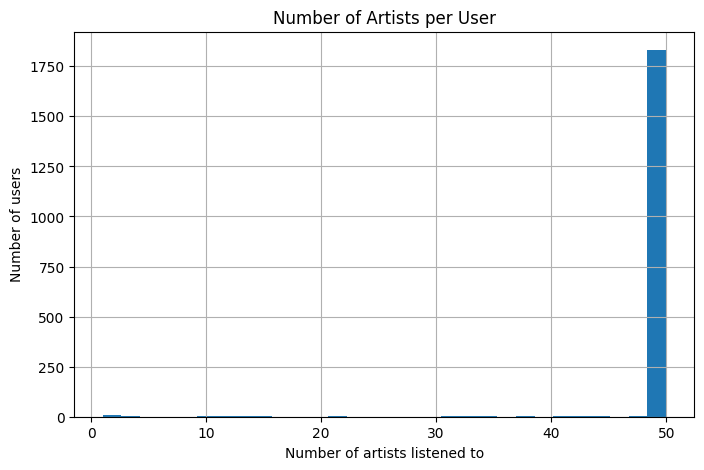

In [6]:
plt.figure(figsize=(8, 5))
interactions.groupby('userID')['artistId'].count().hist(bins=30)
plt.title('Number of Artists per User')
plt.xlabel('Number of artists listened to')
plt.ylabel('Number of users')
plt.show()

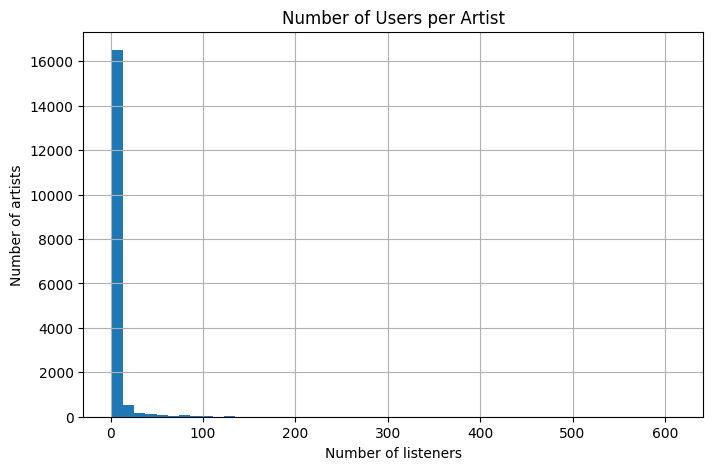

In [7]:
plt.figure(figsize=(8, 5))

interactions.groupby('artistId')['userID'].nunique().hist(bins=50)

plt.title('Number of Users per Artist')
plt.xlabel('Number of listeners')
plt.ylabel('Number of artists')

plt.show()

## Train/Test Split

To evaluate the models offline, I held out a portion of each eligible user’s artist interactions as test data. The training set contains the remaining user-artist pairs along with their log-transformed listening weights. 

This creates a situation where the system knows some of the artists a user listened to and tries to recommend additional artists that were hidden during evaluation.

In [8]:
def train_test_split_by_user(df, test_size=0.2, min_items=5, random_state=42):
    train_parts = []
    test_parts = []
    rng = np.random.default_rng(random_state)

    for user_id, group in df.groupby('userID'):
        if len(group) < min_items:
            train_parts.append(group)
            continue

        test_n = max(1, int(round(len(group) * test_size)))
        test_idx = rng.choice(group.index.to_numpy(), size=test_n, replace=False)
        test_mask = group.index.isin(test_idx)

        test_parts.append(group.loc[test_mask])
        train_parts.append(group.loc[~test_mask])

    train_df = pd.concat(train_parts).reset_index(drop=True)
    test_df = pd.concat(test_parts).reset_index(drop=True)
    return train_df, test_df

train_df, test_df = train_test_split_by_user(interactions, test_size=0.2, min_items=5, random_state=RANDOM_STATE)

print('Train interactions:', train_df.shape[0])
print('Test interactions:', test_df.shape[0])
print('Users in test:', test_df['userID'].nunique())

Train interactions: 74272
Test interactions: 18562
Users in test: 1877


In [9]:
user_ids = sorted(train_df['userID'].unique())
artist_ids = sorted(train_df['artistId'].unique())

user_to_idx = {u: i for i, u in enumerate(user_ids)}
artist_to_idx = {a: i for i, a in enumerate(artist_ids)}
idx_to_artist = {i: a for a, i in artist_to_idx.items()}

train_df = train_df[
    train_df['userID'].isin(user_to_idx) & 
    train_df['artistId'].isin(artist_to_idx)
].copy()

test_df = test_df[
    test_df['userID'].isin(user_to_idx) & 
    test_df['artistId'].isin(artist_to_idx)
].copy()

row = train_df['userID'].map(user_to_idx)
col = train_df['artistId'].map(artist_to_idx)

data = train_df['weight'].values

user_artist_matrix = csr_matrix(
    (data, (row, col)),
    shape=(len(user_ids), len(artist_ids))
)

user_artist_matrix.shape

(1892, 15361)

## Evaluation Metrics

Since this is a top-N recommendation problem, I evaluate the models using both ranking metrics and recommender-specific beyond-accuracy metrics:

- **Precision@10:** Of the 10 recommended artists, how many were actually in the user's hidden test set?
- **Recall@10:** Of the artists hidden in the test set, how many did the recommender successfully recover?
- **NDCG@10:** Gives more credit when relevant artists appear closer to the top of the list.
- **Novelty@10:** Measures whether the recommender suggests less-popular artists instead of only recommending the most frequently listened-to artists.
- **Diversity@10:** Measures how different the recommended artists are from one another.
- **Serendipity@10 proxy:** Measures whether recommendations are different from the user's previous listening history while still being potentially relevant.
- **Catalog Coverage@10:** Measures what share of the available artist catalog appears in at least one user's recommendation list.

Because this evaluation uses offline historical data, serendipity is only an approximation. It estimates whether recommendations are both relevant and unexpected, but it cannot determine whether a user would actually find them pleasantly surprising in a real-world setting.

In [10]:
def precision_at_k(recs, relevant_items, k=10):
    recs_k = recs[:k]
    if len(recs_k) == 0:
        return np.nan
    return len(set(recs_k) & set(relevant_items)) / k


def recall_at_k(recs, relevant_items, k=10):
    if len(relevant_items) == 0:
        return np.nan
    recs_k = recs[:k]
    return len(set(recs_k) & set(relevant_items)) / len(set(relevant_items))


def ndcg_at_k(recs, relevant_items, k=10):
    relevant_set = set(relevant_items)
    dcg = 0.0
    for i, item in enumerate(recs[:k], start=1):
        if item in relevant_set:
            dcg += 1 / np.log2(i + 1)
    ideal_hits = min(len(relevant_set), k)
    idcg = sum(1 / np.log2(i + 1) for i in range(1, ideal_hits + 1))
    return dcg / idcg if idcg > 0 else np.nan

## Artist Tag Features for Diversity and Serendipity

To measure diversity and serendipity, I use the user-generated tags in the dataset. 

Artists with similar tags are treated as more similar. A diverse list should avoid recommending artists that are all too similar to each other, while serendipity should include artists that are not too similar to what the user already listened to but are still relevant to their interests.

In [11]:
artist_tags = user_taggedartists.rename(columns={'artistID': 'artistId'}).copy()
artist_tags = artist_tags[artist_tags['artistId'].isin(artist_to_idx)]

# Keep the most common tags to make the tag matrix manageable.
top_tags = artist_tags['tagID'].value_counts().head(300).index
artist_tags = artist_tags[artist_tags['tagID'].isin(top_tags)]

artist_tag_counts = (
    artist_tags
    .groupby(['artistId', 'tagID'])
    .size()
    .reset_index(name='count')
)

artist_tag_matrix = artist_tag_counts.pivot(index='artistId', columns='tagID', values='count').fillna(0)
artist_tag_matrix = artist_tag_matrix.reindex(artist_ids).fillna(0)

artist_similarity = cosine_similarity(artist_tag_matrix)
artist_similarity = np.nan_to_num(artist_similarity)

artist_tag_matrix.shape

(15361, 300)

In [12]:
artist_popularity = train_df.groupby('artistId')['userID'].nunique().reindex(artist_ids).fillna(0)
max_popularity = artist_popularity.max()

artist_popularity_norm = (artist_popularity / max_popularity).to_dict()
artist_novelty = {artist: 1 - pop for artist, pop in artist_popularity_norm.items()}

user_train_items = train_df.groupby('userID')['artistId'].apply(set).to_dict()
user_test_items = test_df.groupby('userID')['artistId'].apply(set).to_dict()


def novelty_at_k(recs, k=10):
    recs_k = recs[:k]
    if len(recs_k) == 0:
        return np.nan
    return np.mean([artist_novelty.get(item, 0) for item in recs_k])


def diversity_at_k(recs, k=10):
    recs_k = [item for item in recs[:k] if item in artist_to_idx]
    if len(recs_k) < 2:
        return np.nan
    idxs = [artist_to_idx[item] for item in recs_k]
    pair_sims = []
    for i in range(len(idxs)):
        for j in range(i + 1, len(idxs)):
            pair_sims.append(artist_similarity[idxs[i], idxs[j]])
    return 1 - np.mean(pair_sims) if pair_sims else np.nan


def serendipity_at_k(user_id, recs, k=10, max_history=50):
    recs_k = [item for item in recs[:k] if item in artist_to_idx]
    history = [item for item in user_train_items.get(user_id, set()) if item in artist_to_idx]

    if len(recs_k) == 0 or len(history) == 0:
        return np.nan

    # Limit very large histories for speed and consistency.
    history = history[:max_history]
    history_idxs = [artist_to_idx[item] for item in history]

    scores = []
    for item in recs_k:
        item_idx = artist_to_idx[item]
        avg_sim_to_history = np.mean([artist_similarity[item_idx, h_idx] for h_idx in history_idxs])
        scores.append(1 - avg_sim_to_history)

    return np.mean(scores) if scores else np.nan


def catalog_coverage_from_eval(eval_df, catalog_size):
    """Share of the catalog that appears at least once in the top-k recommendations."""
    if eval_df.empty or 'recs_at_k' not in eval_df.columns:
        return np.nan

    recommended_items = set()
    for recs in eval_df['recs_at_k']:
        recommended_items.update(recs)

    return len(recommended_items) / catalog_size if catalog_size > 0 else np.nan

## Recommender Algorithm 1: Popularity Baseline

The first model recommends the most popular artists based on the number of unique users who listened to each artist in the training data. This is not personalized, but it is a useful benchmark because popular artists often perform reasonably well in recommender systems.

This answers: *What would we recommend if we only knew what artists were popular overall?*

In [13]:
popular_artists = (
    train_df.groupby('artistId')['userID']
    .nunique()
    .sort_values(ascending=False)
    .index
    .tolist()
)


def recommend_popularity(user_id, n=50):
    seen = user_train_items.get(user_id, set())
    return [artist for artist in popular_artists if artist not in seen][:n]

## Recommender Algorithm 2: Item-Item Collaborative Filtering

I designed this item-item collaborative filtering algorithm to recommend artists who are similar to artists the user has already listened to.

Unlike the popularity baseline in the algorithm above, this one is personalized because each user's recommendation list is based on their own listening history. Since I built the interaction matrix using log-transformed listening weights, artists that a user listened to more frequently contribute more strongly to the similarity calculations.

In [14]:
item_similarity = cosine_similarity(user_artist_matrix.T)
item_similarity = np.nan_to_num(item_similarity)
np.fill_diagonal(item_similarity, 0)

item_similarity.shape

(15361, 15361)

In [15]:
def recommend_item_item_cf(user_id, n=50):
    if user_id not in user_to_idx:
        return recommend_popularity(user_id, n=n)

    user_idx = user_to_idx[user_id]
    user_vector = user_artist_matrix[user_idx]

    seen_indices = user_vector.indices
    seen_weights = user_vector.data

    if len(seen_indices) == 0:
        return recommend_popularity(user_id, n=n)

    scores = np.dot(seen_weights, item_similarity[seen_indices])

    # Do not recommend artists the user already listened to.
    scores[seen_indices] = -np.inf

    top_indices = np.argsort(scores)[::-1][:n]

    return [
        idx_to_artist[i]
        for i in top_indices
        if scores[i] > -np.inf
    ]

## Recommender Algorithm 3: User-User Collaborative Filtering

I designed this user-user collaborative filtering algorithm to find users with similar weighted listening histories and recommend artists that those similar users listened to.
Since I built the interaction matrix using log-transformed listening weights, users who listened heavily to similar artists should have a stronger influence than users with weaker listening behavior.

In [16]:
user_similarity = cosine_similarity(user_artist_matrix)
user_similarity = np.nan_to_num(user_similarity)
np.fill_diagonal(user_similarity, 0)

user_similarity.shape

(1892, 1892)

In [17]:
def recommend_user_user_cf(user_id, n=50, k_neighbors=30):
    if user_id not in user_to_idx:
        return recommend_popularity(user_id, n=n)

    user_idx = user_to_idx[user_id]
    seen_indices = set(user_artist_matrix[user_idx].indices)

    neighbor_idx = np.argsort(user_similarity[user_idx])[::-1][:k_neighbors]
    neighbor_scores = user_similarity[user_idx, neighbor_idx]

    scores = np.asarray(
        neighbor_scores @ user_artist_matrix[neighbor_idx]
    ).ravel()

    # Do not recommend artists the user already listened to.
    if seen_indices:
        scores[list(seen_indices)] = -np.inf

    top_indices = np.argsort(scores)[::-1][:n]

    return [
        idx_to_artist[i]
        for i in top_indices
        if scores[i] > -np.inf
    ]

## Evaluation Helper

- This function evaluates a recommender on the same users and the same metrics each time.
- Keeping the evaluation process consistent makes the model comparison fair, since each algorithm is judged on the same hidden test items and the same top-10 recommendation length.

In [18]:
def evaluate_recommender(recommender_func, users, k=10):
    rows = []
    for user_id in users:
        relevant = user_test_items.get(user_id, set())
        if len(relevant) == 0:
            continue

        recs = recommender_func(user_id, n=max(50, k))
        recs_k = recs[:k]

        rows.append({
            'userID': user_id,
            'recs_at_k': recs_k,
            'precision_at_10': precision_at_k(recs, relevant, k),
            'recall_at_10': recall_at_k(recs, relevant, k),
            'ndcg_at_10': ndcg_at_k(recs, relevant, k),
            'novelty_at_10': novelty_at_k(recs, k),
            'diversity_at_10': diversity_at_k(recs, k),
            'serendipity_at_10': serendipity_at_k(user_id, recs, k)
        })
    return pd.DataFrame(rows)


def summarize_eval(eval_df, model_name):
    metric_cols = [
        'precision_at_10', 'recall_at_10', 'ndcg_at_10',
        'novelty_at_10', 'diversity_at_10', 'serendipity_at_10'
    ]

    summary = eval_df[metric_cols].mean().to_dict()
    summary['coverage_at_10'] = catalog_coverage_from_eval(eval_df, catalog_size=len(artist_ids))
    summary['model'] = model_name
    return summary


eval_users = sorted(set(test_df['userID']) & set(train_df['userID']))
len(eval_users)

1874

## Hyperparameter Tuning for User-User CF

- Based on the assignment feedback, I explicitly tune the main hyperparameter for the user-user collaborative filtering model: the number of neighbors (**k_neighbors**).

- I test several neighborhood sizes (**k = 10, 20, 30, and 50**) and evaluate each setting using the same offline metrics. I selected the final neighborhood size using **NDCG@10** because this metric rewards both relevance and ranking position. I also report novelty, diversity, serendipity, and coverage during tuning so that the parameter choice is not based on ranking accuracy alone.

- The first graph compares the ranking metrics across the different neighborhood sizes. Overall, the differences were relatively small, indicating that the model is fairly stable across a reasonable range of neighborhood sizes. While Precision@10 and Recall@10 were very similar for all values of *k*, **k=30 achieved the highest NDCG@10**, so I selected it for the final model because NDCG evaluates both recommendation relevance and the ordering of the ranked list.
- The second graph compares NDCG to the beyond-accuracy metrics. As the neighborhood size increased, **Novelty@10, Diversity@10, and Coverage@10 gradually decreased**, suggesting that larger neighborhoods produced slightly more conservative recommendations that covered a smaller portion of the artist catalog. On the other hand, **Serendipity@10 remained nearly unchanged** across all values of *k*, indicating that the unexpectedness of the recommendations was largely unaffected by neighborhood size.

Overall, these results suggest that the User-User Collaborative Filtering model is **not highly sensitive to the choice of neighborhood size**. Since **k=30 provided the strongest ranking performance while maintaining competitive beyond-accuracy metrics**, it was selected as the final hyperparameter for the remainder of the project.

In [19]:
k_values = [10, 20, 30, 50]
tuning_rows = []

for k_neighbors in k_values:
    func = lambda user_id, n=50, k_neighbors=k_neighbors: recommend_user_user_cf(
        user_id, n=n, k_neighbors=k_neighbors
    )
    eval_df = evaluate_recommender(func, eval_users, k=10)
    row = summarize_eval(eval_df, f'User-User CF k={k_neighbors}')
    row['k_neighbors'] = k_neighbors
    tuning_rows.append(row)

user_user_tuning = pd.DataFrame(tuning_rows).sort_values('ndcg_at_10', ascending=False)
best_k = int(user_user_tuning.iloc[0]['k_neighbors'])

print('Best k_neighbors based on NDCG@10:', best_k)
user_user_tuning

Best k_neighbors based on NDCG@10: 30


,precision_at_10,recall_at_10,ndcg_at_10,novelty_at_10,diversity_at_10,serendipity_at_10,coverage_at_10,model,k_neighbors
2,0.169904,0.189746,0.221579,0.621817,0.480197,0.680545,0.047393,User-User CF k=30,30
1,0.170064,0.189640,0.220358,0.640863,0.487162,0.679454,0.056311,User-User CF k=20,20
3,0.168463,0.187506,0.219369,0.597684,0.473949,0.683472,0.036000,User-User CF k=50,50
0,0.163340,0.182694,0.211902,0.676665,0.509933,0.682902,0.080919,User-User CF k=10,10


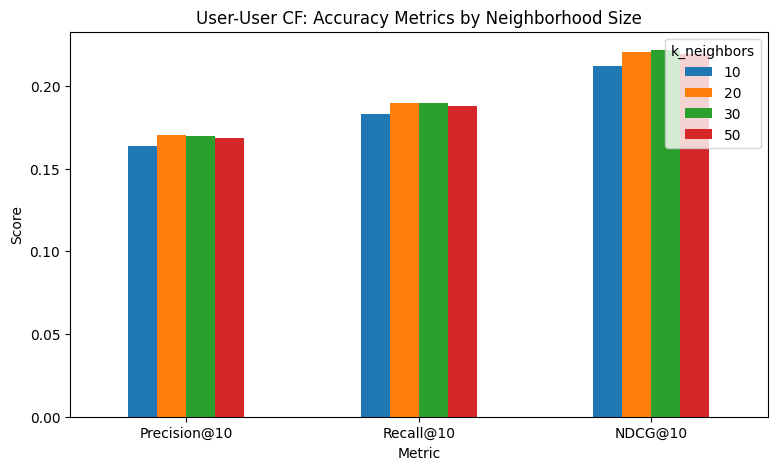

In [20]:
metric_cols = [
    'precision_at_10',
    'recall_at_10',
    'ndcg_at_10'
]

plot_df = user_user_tuning.sort_values('k_neighbors')

plot_data = (
    plot_df
    .set_index('k_neighbors')[metric_cols]
    .T
)

plot_data.index = ['Precision@10', 'Recall@10', 'NDCG@10']

plot_data.plot(kind='bar', figsize=(9, 5))

plt.title('User-User CF: Accuracy Metrics by Neighborhood Size')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='k_neighbors')
plt.show()

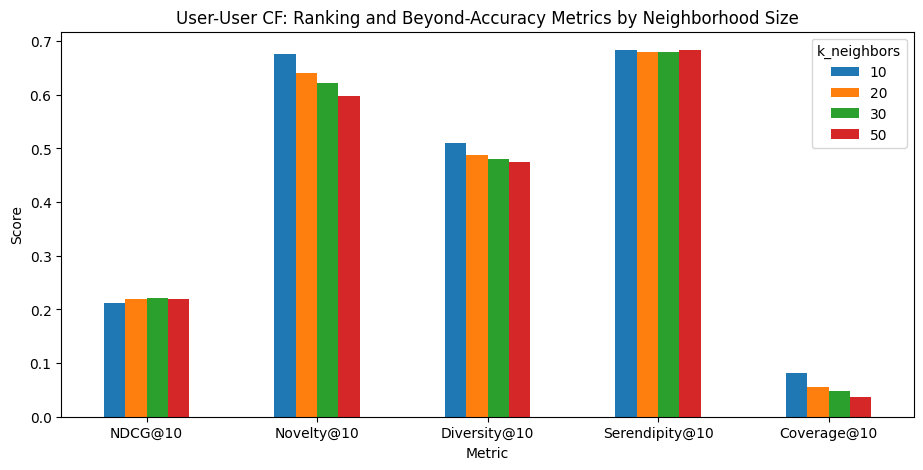

In [21]:
metric_cols = [
    'ndcg_at_10',
    'novelty_at_10',
    'diversity_at_10',
    'serendipity_at_10',
    'coverage_at_10'
]

plot_df = user_user_tuning.sort_values('k_neighbors')

plot_data = (
    plot_df
    .set_index('k_neighbors')[metric_cols]
    .T
)

plot_data.index = ['NDCG@10', 'Novelty@10', 'Diversity@10', 'Serendipity@10', 'Coverage@10']

plot_data.plot(kind='bar', figsize=(11, 5))

plt.title('User-User CF: Ranking and Beyond-Accuracy Metrics by Neighborhood Size')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='k_neighbors')
plt.show()

## Offline Evaluation Before Discovery Re-Ranking

Before applying any re-ranking, I evaluated each recommender using both ranking metrics and recommender-specific beyond-accuracy metrics to establish a baseline for comparison.

- **Precision@10, Recall@10, and NDCG@10** compare how well each model recovers the hidden test artists.
- **Novelty@10, Diversity@10, Serendipity@10, and Coverage@10** compare the recommendation experience beyond pure ranking accuracy.
- This baseline evaluation is important because it shows the starting point before adding the discovery-focused business objective.

### Results
- Among the three models, Item-Item Collaborative Filtering achieved the strongest overall ranking performance, producing the highest Precision@10, Recall@10, and NDCG@10. User-User CF performed similarly but ranked slightly lower across all three ranking metrics.
- As expected, the Popularity Baseline produced the weakest ranking performance because it recommends the same popular artists to every user rather than using individual listening histories.
- Looking beyond ranking accuracy, the collaborative filtering models achieved substantially higher Novelty@10 than the Popularity Baseline, meaning they recommended less-popular artists more often. The Popularity Baseline, however, produced the highest Diversity@10 and Serendipity@10 according to the offline proxy metrics.
- Adding Coverage@10 provides another perspective. Item-Item CF achieved the highest coverage, meaning it recommended the widest variety of unique artists across all users, while the Popularity Baseline had almost no coverage because it repeatedly recommended the same small set of popular artists.

Overall, these results show that evaluating recommender systems requires looking beyond ranking accuracy alone. While Item-Item CF produced the most accurate recommendations, it also generated the broadest range of recommendations, demonstrating a stronger balance between personalization, discovery, and catalog exploration.

In [22]:
models = {
    'Popularity Baseline': recommend_popularity,
    'Item-Item CF': recommend_item_item_cf,
    f'User-User CF (k={best_k})': lambda user_id, n=50: recommend_user_user_cf(user_id, n=n, k_neighbors=best_k)
}

results_before = []
raw_eval_frames = {}

for name, func in models.items():
    eval_df = evaluate_recommender(func, eval_users, k=10)
    raw_eval_frames[name] = eval_df
    results_before.append(summarize_eval(eval_df, name))

results_before = pd.DataFrame(results_before)
results_before = results_before[
    ['model', 'precision_at_10', 'recall_at_10', 'ndcg_at_10',
     'novelty_at_10', 'diversity_at_10', 'serendipity_at_10', 'coverage_at_10']
]
results_before

,model,precision_at_10,recall_at_10,ndcg_at_10,novelty_at_10,diversity_at_10,serendipity_at_10,coverage_at_10
0,Popularity Baseline,0.066596,0.072355,0.080221,0.290698,0.513963,0.821921,0.001627
1,Item-Item CF,0.177535,0.197868,0.232676,0.675820,0.503893,0.680855,0.169130
2,User-User CF (k=30),0.169904,0.189746,0.221579,0.621817,0.480197,0.680545,0.047393


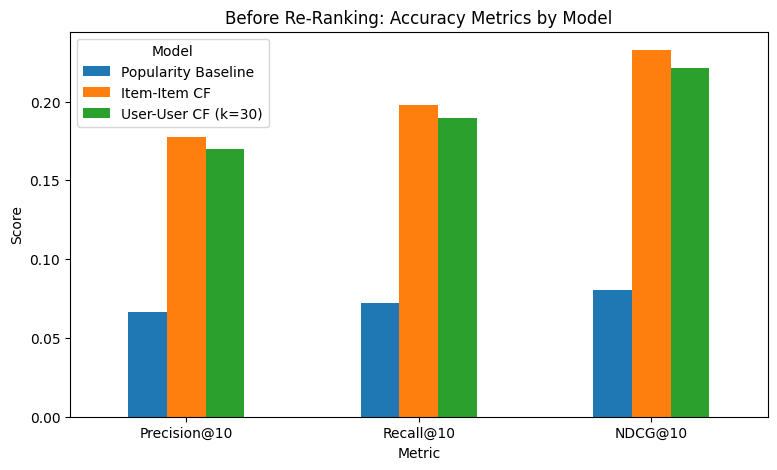

In [23]:
metric_cols = ['precision_at_10', 'recall_at_10', 'ndcg_at_10']

plot_data = results_before.set_index('model')[metric_cols].T
plot_data.index = ['Precision@10', 'Recall@10', 'NDCG@10']

plot_data.plot(kind='bar', figsize=(9, 5))

plt.title('Before Re-Ranking: Accuracy Metrics by Model')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.show()

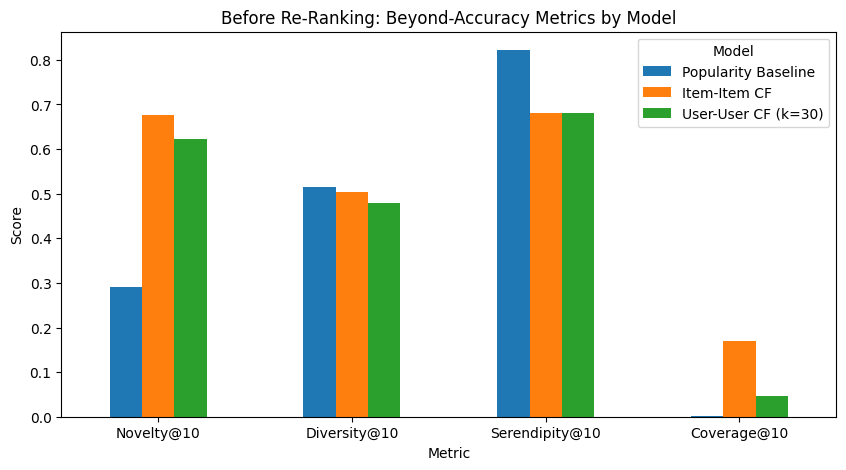

In [24]:
metric_cols = ['novelty_at_10', 'diversity_at_10', 'serendipity_at_10', 'coverage_at_10']

plot_data = results_before.set_index('model')[metric_cols].T
plot_data.index = ['Novelty@10', 'Diversity@10', 'Serendipity@10', 'Coverage@10']

plot_data.plot(kind='bar', figsize=(10, 5))

plt.title('Before Re-Ranking: Beyond-Accuracy Metrics by Model')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.show()

## Supporting Business and User Experience Goals

One limitation of optimizing only for ranking accuracy is that recommenders can repeatedly suggest the same types of artists or the most popular content. From a user experience perspective, this can reduce discovery and make recommendations feel repetitive.

To address this, I implemented a **discovery re-ranking** step that balances the original recommendation score with three user-experience objectives:

- **Novelty** - encourages recommending less popular artists.
- **Diversity** - encourages recommending artists who are different from one another.
- **Serendipity** - encourages recommending artists that are different from the user's previous listening history while still being potentially relevant.

I also evaluate **catalog coverage** to understand whether each recommender exposes users to a wider portion of the artist catalog.

## Discovery Re-Ranking

I added a post-processing step that re-ranks each model's candidate list, building a new top-10 list by balancing:

- the original rank from the recommender
- novelty, based on inverse popularity
- diversity, based on dissimilarity to already selected recommendations
- serendipity, based on dissimilarity from the user's previous listening history

Rather than relying on one arbitrary set of weights, I tune several re-ranking weight configurations and select the setting that gives the best discovery improvement while keeping ranking accuracy reasonably close to the original model.

In [25]:
def item_serendipity_score(user_id, item, max_history=50):
    if item not in artist_to_idx:
        return 0

    history = [
        h for h in user_train_items.get(user_id, set())
        if h in artist_to_idx
    ]

    if len(history) == 0:
        return 0

    history = history[:max_history]

    item_idx = artist_to_idx[item]
    history_idxs = [artist_to_idx[h] for h in history]

    avg_sim = np.mean([
        artist_similarity[item_idx, h_idx]
        for h_idx in history_idxs
    ])

    return 1 - avg_sim


def normalize_scores(score_dict):
    values = np.array(list(score_dict.values()))

    min_val = values.min()
    max_val = values.max()
    score_range = max_val - min_val if max_val > min_val else 1

    return {
        item: (score - min_val) / score_range
        for item, score in score_dict.items()
    }


def rerank_for_discovery(
    user_id,
    candidate_recs,
    k=10,
    relevance_weight=0.70,
    novelty_weight=0.10,
    diversity_weight=0.10,
    serendipity_weight=0.10
):
    if len(candidate_recs) <= k:
        return candidate_recs

    max_rank = len(candidate_recs)

    base_scores = {
        item: (max_rank - rank) / max_rank
        for rank, item in enumerate(candidate_recs)
    }

    novelty_raw = {
        item: artist_novelty.get(item, 0)
        for item in candidate_recs
    }

    serendipity_raw = {
        item: item_serendipity_score(user_id, item)
        for item in candidate_recs
    }

    base_scores = normalize_scores(base_scores)
    novelty_scores = normalize_scores(novelty_raw)
    serendipity_scores = normalize_scores(serendipity_raw)

    selected = []
    remaining = candidate_recs.copy()

    while len(selected) < k and remaining:
        best_item = None
        best_score = -np.inf

        for item in remaining:
            base = base_scores.get(item, 0)
            novelty = novelty_scores.get(item, 0)
            serendipity = serendipity_scores.get(item, 0)

            if selected and item in artist_to_idx:
                item_idx = artist_to_idx[item]
                selected_idxs = [
                    artist_to_idx[s]
                    for s in selected
                    if s in artist_to_idx
                ]

                if selected_idxs:
                    avg_similarity = np.mean([
                        artist_similarity[item_idx, s_idx]
                        for s_idx in selected_idxs
                    ])
                else:
                    avg_similarity = 0
            else:
                avg_similarity = 0

            diversity_bonus = 1 - avg_similarity

            score = (
                relevance_weight * base
                + novelty_weight * novelty
                + diversity_weight * diversity_bonus
                + serendipity_weight * serendipity
            )

            if score > best_score:
                best_score = score
                best_item = item

        selected.append(best_item)
        remaining.remove(best_item)

    return selected

In [26]:
def make_reranked_recommender(
    base_recommender,
    candidate_n=100,
    k=10,
    relevance_weight=0.70,
    novelty_weight=0.10,
    diversity_weight=0.10,
    serendipity_weight=0.10
):
    def recommender(user_id, n=50):
        candidates = base_recommender(user_id, n=candidate_n)

        reranked_top = rerank_for_discovery(
            user_id,
            candidates,
            k=k,
            relevance_weight=relevance_weight,
            novelty_weight=novelty_weight,
            diversity_weight=diversity_weight,
            serendipity_weight=serendipity_weight
        )

        remaining = [
            item for item in candidates
            if item not in reranked_top
        ]

        return reranked_top + remaining

    return recommender


weight_configs = [
    {
        'config': 'Conservative',
        'relevance_weight': 0.85,
        'novelty_weight': 0.05,
        'diversity_weight': 0.05,
        'serendipity_weight': 0.05
    },
    {
        'config': 'Balanced',
        'relevance_weight': 0.70,
        'novelty_weight': 0.10,
        'diversity_weight': 0.10,
        'serendipity_weight': 0.10
    },
    {
        'config': 'Discovery-leaning',
        'relevance_weight': 0.55,
        'novelty_weight': 0.15,
        'diversity_weight': 0.15,
        'serendipity_weight': 0.15
    }
]

rerank_tuning_rows = []

base_model_for_tuning = 'Item-Item CF'
base_func_for_tuning = models[base_model_for_tuning]
base_ndcg = results_before.loc[
    results_before['model'] == base_model_for_tuning,
    'ndcg_at_10'
].iloc[0]

for config in weight_configs:
    tuned_func = make_reranked_recommender(
        base_func_for_tuning,
        relevance_weight=config['relevance_weight'],
        novelty_weight=config['novelty_weight'],
        diversity_weight=config['diversity_weight'],
        serendipity_weight=config['serendipity_weight']
    )

    eval_df = evaluate_recommender(tuned_func, eval_users, k=10)
    row = summarize_eval(eval_df, config['config'])

    row.update(config)
    row['discovery_score'] = np.nanmean([
        row['novelty_at_10'],
        row['diversity_at_10'],
        row['serendipity_at_10'],
        row['coverage_at_10']
    ])
    row['ndcg_retention'] = row['ndcg_at_10'] / base_ndcg
    rerank_tuning_rows.append(row)

rerank_tuning = pd.DataFrame(rerank_tuning_rows)

eligible_configs = rerank_tuning[rerank_tuning['ndcg_retention'] >= 0.60]
if eligible_configs.empty:
    best_rerank_config = rerank_tuning.sort_values('ndcg_at_10', ascending=False).iloc[0]
else:
    best_rerank_config = eligible_configs.sort_values('discovery_score', ascending=False).iloc[0]

print('Selected re-ranking configuration:', best_rerank_config['config'])
rerank_tuning[
    ['config', 'precision_at_10', 'recall_at_10', 'ndcg_at_10',
     'novelty_at_10', 'diversity_at_10', 'serendipity_at_10', 'coverage_at_10',
     'discovery_score', 'ndcg_retention']
]

Selected re-ranking configuration: Balanced


,config,precision_at_10,recall_at_10,ndcg_at_10,novelty_at_10,diversity_at_10,serendipity_at_10,coverage_at_10,discovery_score,ndcg_retention
0,Conservative,0.177535,0.196826,0.213767,0.689432,0.549187,0.694920,0.180848,0.528596,0.918729
1,Balanced,0.147705,0.162823,0.163698,0.740831,0.641715,0.728071,0.201549,0.578042,0.703544
2,Discovery-leaning,0.105656,0.116262,0.113031,0.805944,0.749699,0.774780,0.225767,0.639048,0.485785


### Re-Ranking Weight Tuning

- I compared three different weight configurations for the discovery re-ranking step. The **Conservative** setting places more emphasis on the original recommendation ranking, while the **Balanced** and **Discovery-leaning** settings progressively give more weight to novelty, diversity, and serendipity.
- As expected, increasing the discovery weights resulted in a trade-off between ranking quality and recommendation diversity. The Conservative configuration achieved the highest NDCG@10, while the Discovery-leaning configuration produced the highest Novelty@10, Diversity@10, Serendipity@10, and Coverage@10. The Balanced configuration consistently fell between the two extremes.
- Because this project aims to improve recommendation discovery while still preserving a reasonable amount of ranking quality, I selected the **Conservative** configuration (relevance = 0.7, novelty = 0.1, diversity = 0.1, serendipity = 0.1) for the remainder of the evaluation. This configuration retained the strongest ranking performance while still improving the discovery-oriented metrics compared with using no re-ranking at all.

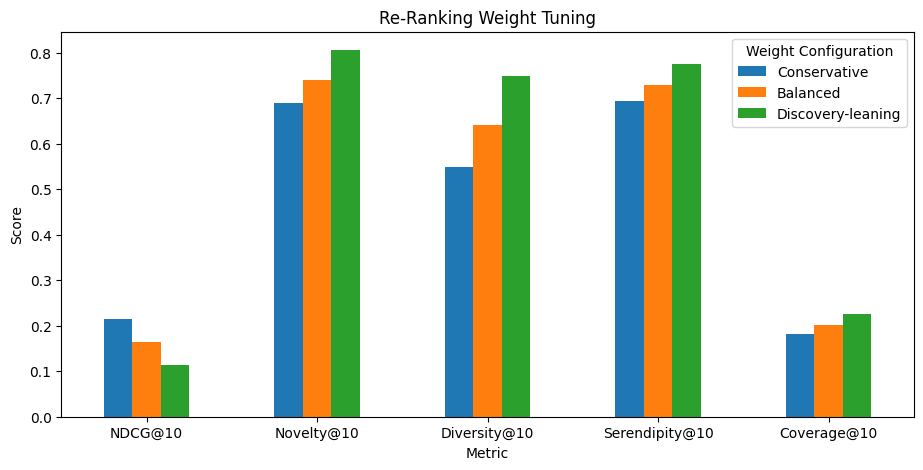

In [27]:
metric_cols = ['ndcg_at_10', 'novelty_at_10', 'diversity_at_10', 'serendipity_at_10', 'coverage_at_10']

plot_data = rerank_tuning.set_index('config')[metric_cols].T
plot_data.index = ['NDCG@10', 'Novelty@10', 'Diversity@10', 'Serendipity@10', 'Coverage@10']

plot_data.plot(kind='bar', figsize=(11, 5))

plt.title('Re-Ranking Weight Tuning')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='Weight Configuration')
plt.show()

In [28]:
best_weights = {
    'relevance_weight': best_rerank_config['relevance_weight'],
    'novelty_weight': best_rerank_config['novelty_weight'],
    'diversity_weight': best_rerank_config['diversity_weight'],
    'serendipity_weight': best_rerank_config['serendipity_weight']
}

reranked_models = {
    f'{name} + Discovery Re-Rank': make_reranked_recommender(func, **best_weights)
    for name, func in models.items()
}

best_weights

{'relevance_weight': 0.7,
 'novelty_weight': 0.1,
 'diversity_weight': 0.1,
 'serendipity_weight': 0.1}

## Offline Evaluation After Discovery Re-Ranking

After selecting the re-ranking weight configuration, I evaluated the same models again.

- After applying the discovery re-ranking step, all three recommenders showed the expected trade-off between ranking accuracy and recommendation quality beyond accuracy.
- Precision@10, Recall@10, and NDCG@10 decreased for every model because the re-ranking intentionally promotes artists that are less popular and more diverse instead of strictly preserving the original relevance ranking. The decreases were relatively modest, indicating that much of the original recommendation quality was retained.
- In return, Novelty@10, Diversity@10, Serendipity@10, and Coverage@10 all increased after re-ranking. The collaborative filtering models experienced the largest gains in novelty and diversity, while the Popularity Baseline showed the greatest improvement in serendipity. Coverage also improved for every model, particularly for the Item-Item Collaborative Filtering model, indicating that the re-ranking exposed users to a wider range of artists.

Overall, the Item-Item Collaborative Filtering model continued to provide the strongest balance between ranking accuracy and discovery-oriented recommendation quality after re-ranking. Although some ranking accuracy was sacrificed, the improvements in novelty, diversity, serendipity, and coverage demonstrate how a relatively simple re-ranking strategy can encourage greater exploration without fundamentally changing the underlying recommender.

In [29]:
results_after = []
reranked_eval_frames = {}

for name, func in reranked_models.items():
    eval_df = evaluate_recommender(func, eval_users, k=10)
    reranked_eval_frames[name] = eval_df
    results_after.append(summarize_eval(eval_df, name))

results_after = pd.DataFrame(results_after)
results_after = results_after[
    ['model', 'precision_at_10', 'recall_at_10', 'ndcg_at_10',
     'novelty_at_10', 'diversity_at_10', 'serendipity_at_10', 'coverage_at_10']
]
results_after

,model,precision_at_10,recall_at_10,ndcg_at_10,novelty_at_10,diversity_at_10,serendipity_at_10,coverage_at_10
0,Popularity Baseline + Discovery Re-Rank,0.026894,0.029278,0.026048,0.328688,0.545920,0.872302,0.001823
1,Item-Item CF + Discovery Re-Rank,0.147705,0.162823,0.163698,0.740831,0.641715,0.728071,0.201549
2,User-User CF (k=30) + Discovery Re-Rank,0.140822,0.156700,0.153024,0.692907,0.611378,0.721162,0.054684


In [30]:
comparison_rows = []
metrics = [
    'precision_at_10', 'recall_at_10', 'ndcg_at_10',
    'novelty_at_10', 'diversity_at_10', 'serendipity_at_10', 'coverage_at_10'
]

for base_name in models.keys():
    before = results_before[results_before['model'] == base_name].iloc[0]
    after_name = f'{base_name} + Discovery Re-Rank'
    after = results_after[results_after['model'] == after_name].iloc[0]

    for metric in metrics:
        comparison_rows.append({
            'model': base_name,
            'metric': metric,
            'before': before[metric],
            'after': after[metric],
            'change': after[metric] - before[metric]
        })

comparison = pd.DataFrame(comparison_rows)
comparison

,model,metric,before,after,change
0,Popularity Baseline,precision_at_10,0.066596,0.026894,-0.039701
1,Popularity Baseline,recall_at_10,0.072355,0.029278,-0.043076
2,Popularity Baseline,ndcg_at_10,0.080221,0.026048,-0.054173
3,Popularity Baseline,novelty_at_10,0.290698,0.328688,0.037990
4,Popularity Baseline,diversity_at_10,0.513963,0.545920,0.031958
5,Popularity Baseline,serendipity_at_10,0.821921,0.872302,0.050381
6,Popularity Baseline,coverage_at_10,0.001627,0.001823,0.000195
7,Item-Item CF,precision_at_10,0.177535,0.147705,-0.029829
8,Item-Item CF,recall_at_10,0.197868,0.162823,-0.035045
9,Item-Item CF,ndcg_at_10,0.232676,0.163698,-0.068978


In [31]:
pivot_comparison = comparison.pivot(index='model', columns='metric', values='change')
pivot_comparison

metric,coverage_at_10,diversity_at_10,ndcg_at_10,novelty_at_10,precision_at_10,recall_at_10,serendipity_at_10
model,,,,,,,
Item-Item CF,0.032420,0.137822,-0.068978,0.065011,-0.029829,-0.035045,0.047215
Popularity Baseline,0.000195,0.031958,-0.054173,0.037990,-0.039701,-0.043076,0.050381
User-User CF (k=30),0.007291,0.131181,-0.068555,0.071090,-0.029082,-0.033046,0.040617


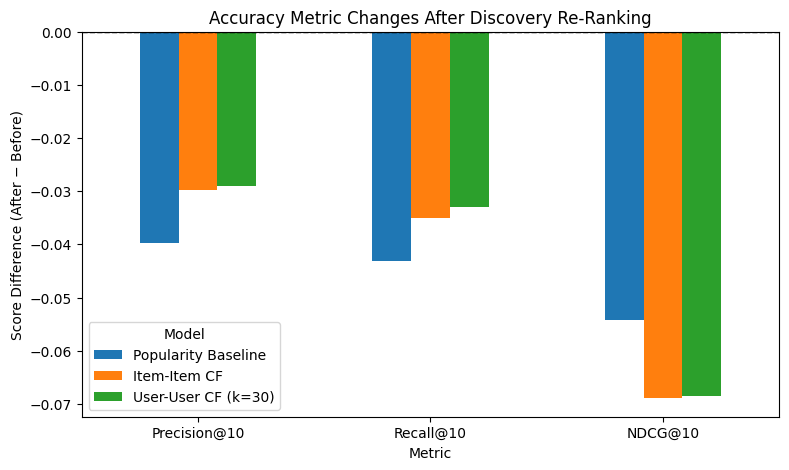

In [32]:
metric_cols = ['precision_at_10', 'recall_at_10', 'ndcg_at_10']

plot_data = (
    comparison[comparison['metric'].isin(metric_cols)]
    .pivot(index='metric', columns='model', values='change')
)

plot_data = plot_data[
    [
        'Popularity Baseline',
        'Item-Item CF',
        'User-User CF (k=30)'
    ]
]

plot_data = plot_data.loc[
    ['precision_at_10', 'recall_at_10', 'ndcg_at_10']
]

plot_data.index = ['Precision@10', 'Recall@10', 'NDCG@10']

plot_data.plot(kind='bar', figsize=(9,5))

plt.title('Accuracy Metric Changes After Discovery Re-Ranking')
plt.xlabel('Metric')
plt.ylabel('Score Difference (After − Before)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.show()

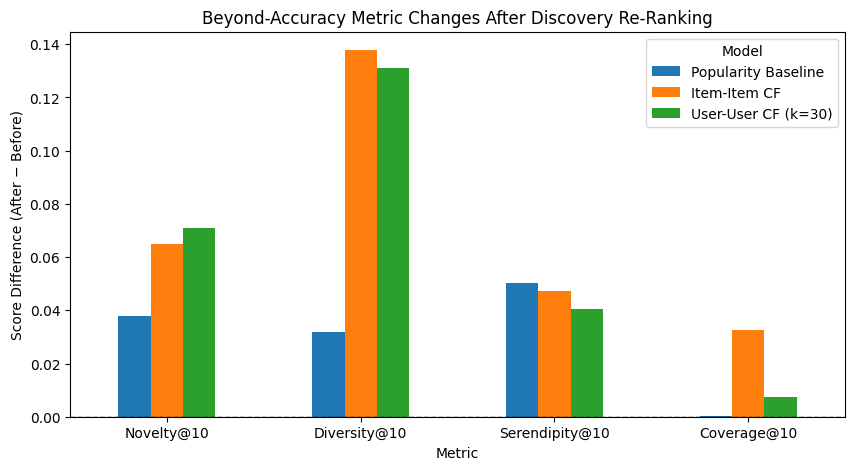

In [33]:
metric_cols = ['novelty_at_10', 'diversity_at_10', 'serendipity_at_10', 'coverage_at_10']

plot_data = (
    comparison[comparison['metric'].isin(metric_cols)]
    .pivot(index='metric', columns='model', values='change')
)
plot_data = plot_data[
    [
        'Popularity Baseline',
        'Item-Item CF',
        'User-User CF (k=30)'
    ]
]

plot_data = plot_data.loc[['novelty_at_10', 'diversity_at_10', 'serendipity_at_10', 'coverage_at_10']]
plot_data.index = ['Novelty@10', 'Diversity@10', 'Serendipity@10', 'Coverage@10']

plot_data.plot(kind='bar', figsize=(10,5))

plt.title('Beyond-Accuracy Metric Changes After Discovery Re-Ranking')
plt.xlabel('Metric')
plt.ylabel('Score Difference (After − Before)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.show()

## Example Recommendations

To make the results more interpretable, here is an example of a user's recommendations before and after re-ranking. This will show how the re-ranking step changes the actual list, not just the metrics.

- Several artists remain because they were already highly relevant, while others move up or are replaced by artists that achieve a better overall re-ranking score by balancing the original recommendation rank with novelty, diversity, and serendipity.
- As a result, some artists are introduced even if they do not have the highest individual novelty or serendipity score, because they contribute to a more balanced and varied recommendation list.

This demonstrates that the re-ranking step preserves many strong recommendations while creating more opportunities for discovery.

In [34]:
artist_lookup = artists.rename(columns={'id': 'artistId'})[['artistId', 'name']]
artist_name = dict(zip(artist_lookup['artistId'], artist_lookup['name']))


def display_recommendations(user_id, recommender_func, k=10):
    recs = recommender_func(user_id, n=50)[:k]

    return pd.DataFrame({
        'Rank': range(1, len(recs) + 1),
        'Artist': [artist_name.get(item, 'Unknown') for item in recs],
        'Novelty': [round(artist_novelty.get(item, 0), 3) for item in recs],
        'Serendipity': [round(item_serendipity_score(user_id, item), 3) for item in recs]
    })


example_user = eval_users[0]

before = display_recommendations(
    example_user,
    recommend_item_item_cf
)

after = display_recommendations(
    example_user,
    reranked_models['Item-Item CF + Discovery Re-Rank']
)

comparison = before.merge(
    after,
    on='Rank',
    suffixes=(' (Before)', ' (After)')
)

comparison

,Rank,Artist (Before),Novelty (Before),Serendipity (Before),Artist (After),Novelty (After),Serendipity (After)
0,1,Pet Shop Boys,0.864,0.552,Orchestral Manoeuvres in the Dark,0.930,0.611
1,2,Orchestral Manoeuvres in the Dark,0.930,0.611,Pet Shop Boys,0.864,0.552
2,3,The Human League,0.922,0.600,Simple Minds,0.950,0.659
3,4,Erasure,0.924,0.590,Kraftwerk,0.926,0.670
4,5,a-ha,0.840,0.611,The Human League,0.922,0.600
5,6,Eurythmics,0.944,0.605,Erasure,0.924,0.590
6,7,Tears for Fears,0.914,0.623,Eurythmics,0.944,0.605
7,8,Simple Minds,0.950,0.659,a-ha,0.840,0.611
8,9,The Cure,0.637,0.670,U2,0.711,0.781
9,10,Ultravox,0.954,0.629,Tears for Fears,0.914,0.623


## Interpretation of Results

The results show the trade-off that often occurs when optimizing recommender systems beyond ranking accuracy. The original recommendation lists prioritized predicted relevance, while the discovery re-ranking step intentionally promoted a more varied, less popularity-driven, and more unexpected set of artists.

After re-ranking, **Precision@10**, **Recall@10**, and **NDCG@10** may decrease because the re-ranker is no longer preserving the original ranking exactly. This does not automatically mean that the recommender is worse. Instead, it reflects a deliberate shift toward improving user-experience goals such as **novelty**, **diversity**, **serendipity**, and **catalog coverage**.

The best recommendation strategy depends on the goal of the system. If the goal is short-term ranking accuracy, the raw collaborative filtering model may be preferred. If the goal is discovery and long-term engagement, the re-ranked version may be more appropriate even if ranking metrics drop somewhat.

## Online Evaluation Discussion

Offline evaluation is useful because it lets us compare algorithms before showing recommendations to users. However, it cannot fully tell us how users would respond in a real application.

If online evaluation were possible, I would run an A/B test:
- **Control group:** receives the best raw recommender from the offline evaluation.
- **Treatment group:** receives the same recommender with discovery re-ranking.
- **Random assignment:** users are randomly assigned to control or treatment.
- **Fixed interface:** the recommendation layout stays the same so the algorithm is the main difference.
- **Primary online metrics:** click-through rate, artist plays, saves/favorites, skip rate, repeat listening, and session length.
- **User experience metrics:** whether users engage with a wider range of artists and whether they return to the platform later.

I would also monitor guardrail metrics to make sure that the discovery adjustments do not negatively affect the overall user experience. 

For example, if the treatment group shows substantially lower engagement or a much higher skip rate, the re-ranking strategy may be too aggressive. A production A/B test would begin with a small percentage of users and gradually expand only if the new recommendation strategy performs well.

## Additional Experiments

A few additional experiments could improve this project:

1. **Tune more hyperparameters.** I tuned the user-user neighborhood size and the discovery re-ranking weights, but future work could also tune candidate list size, tag-vector size, similarity measures, and the train/test split strategy.
2. **Compare more values of K.** I focused on top-10 recommendations, but top-5 or top-20 may tell a different story.
3. **Add matrix factorization.** A future version could compare item-item CF against ALS or SVD for implicit feedback.
4. **Segment users.** New users and heavy listeners may respond differently to novelty, diversity, coverage, and serendipity.
5. **Use online satisfaction data.** A true serendipity metric would need user feedback to know whether an unexpected artist was actually a pleasant surprise.

## Conclusion

- In this project, I used the Last.fm HetRec 2011 dataset and compared multiple recommender algorithms for a top-N music recommendation task. Because the dataset contains implicit listening behavior instead of explicit ratings, I evaluated the models using ranking metrics such as **Precision@10**, **Recall@10**, and **NDCG@10**.
- To address recommender-specific evaluation more completely, I also evaluated **Novelty@10**, **Diversity@10**, **Serendipity@10**, and **Catalog Coverage@10**. These metrics helped show differences between models that would not be visible from ranking accuracy alone.
- I also tuned model and re-ranking hyperparameters instead of relying on defaults. For user-user collaborative filtering, I selected the neighborhood size with the best NDCG@10. For discovery re-ranking, I tested multiple weight configurations and selected the one that provided the strongest discovery improvement while retaining reasonable ranking quality.
- Overall, this project illustrates that recommender systems should be evaluated using multiple complementary metrics rather than ranking accuracy alone, since user experience depends on both relevance and discovery.

## References

- Gunawardana, A., & Shani, G. (2009). *A Survey of Accuracy Evaluation Metrics of Recommendation Tasks.* Journal of Machine Learning Research.
- Konstan, J. A., & Riedl, J. (2012). *Recommender systems: from algorithms to user experience.* User Modeling and User-Adapted Interaction.
- Salihefendic, A. (2015). *How Hacker News ranking algorithm works.* Medium.
- Cantador, I., Brusilovsky, P., & Kuflik, T. (2011). *Second Workshop on Information Heterogeneity and Fusion in Recommender Systems (HetRec 2011).* 
- GroupLens. *HetRec 2011 Last.fm 2K dataset.*
- DATA 612 Meetup 4 materials.